### **Il problema fisico :**

Supponiamo di guardare i "getti" di particelle (i jet) che escono da una collisione. La maggior parte sono jet normali, prodotti dalla forza forte ordinaria: li chiamiamo **QCD.** Sono il "rumore di fondo", il background. Le particelle dentro un jet normale nascono praticamente tutte dal punto di collisione e decadono subito.

Gli **Emerging Jets (EJ)** sono l'ipotesi esotica che stiamo cercando: nascono da ipotetiche particelle di "materia oscura" che vivono abbastanza a lungo da viaggiare dentro il rivelatore prima di decadere. Risultato: le loro tracce non partono dal centro, ma "emergono" da punti spostati (**displaced**), più lontani dall'asse del fascio.

**L'idea del progetto:** non insegniamo al modello com'è fatto un EJ. Gli facciamo studiare solo com'è fatto un jet QCD normale. Poi gli mostriamo un jet: se "non torna", se il modello fatica a ricostruirlo/riconoscerlo come normale → è un'anomalia, candidato EJ.

`È anomaly detection non supervisionata` : Il modello (autoencoder, VAE, ecc.) viene addestrato a **minimizzare un errore di ricostruzione** solo **sulla distribuzione del background QCD.** Al test, lo score di anomalia (es. errore di ricostruzione) sarà mediamente più alto sul segnale EJ, che vive in una regione dello spazio delle feature poco popolata dal QCD. La metrica di valutazione è l'AUC della ROC che separa QCD da EJ usando quello score. La firma fisica chiave dell'EJ è il displacement delle tracce (parametri d'impatto d0, z0 grandi) e una molteplicità di tracce più alta.

### **Che cos'è il preprocessing?**

Il preprocessing è tutta la fase di lavoro che sta tra i dati grezzi e il modello. I dati che escono dal rivelatore non sono mai pronti per essere dati in pasto a una rete neurale: hanno scale diverse, valori mancanti, outlier, formati non uniformi. Il preprocessing serve a trasformarli in input puliti, normalizzati e strutturati in modo che il modello possa imparare bene e in modo stabile.

# Emerging Jets — Preprocessing FINALE 


### Principi metodologici 
1. **Si allena solo sul QCD (background).**
2. **Normalizzazione =** (`norm_dict.yaml`).
3. **Niente label.** Escludiamo label (`isDisplaced`, `isTagged`), classificatori pre-addestrati
   (`salt_pdisp`), feature truth-level (`truth*`, `VSI*`) e teniamo `displacedPtFraction` dietro un flag
   (è troppo vicina al concetto di displacement → si comporta come inserire una labrl, rovina le performance).


### Output 
- **Rappr. 1** — Embedding aggregato per jet (jet-features + statistiche robuste delle tracce)
- **Rappr. 2** — Sequenze padded `(N, 200, F)` + maschera (per Transformer)
- **Rappr. 3** — Grafi kNN (spazio η–φ e spazio dei parametri d'impatto) per le GNN 


## 0. Setup e import

In [1]:
import os, warnings, json
from pathlib import Path

import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

# PyTorch Geometric e' opzionale
try:
    import torch
    from torch_geometric.data import Data
    HAS_PYG = True
except Exception:
    HAS_PYG = False

warnings.filterwarnings("ignore", category=RuntimeWarning)  # mi uscivano troppi warning sui nan, ho tolto
np.random.seed(42) #riproducibilità, anche quelli dopo usano 42 --> Fissare il "seme" a 42 vuol dire: "parti sempre dallo stesso punto"

# Stile grafici
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3,
})
sns.set_context("notebook")

COLOR_QCD = "#1f77b4"   # blu  = background QCD
COLOR_EJ  = "#d62728"   # rosso = Emerging Jets 

print("h5py", h5py.__version__, "| PyTorch Geometric disponibile:", HAS_PYG)

h5py 3.16.0 | PyTorch Geometric disponibile: False


## 0.5 Esplorazione dei dati 
Prima di decidere *quali* feature usare, guardiamo i file: struttura HDF5, shape, dtype e un
**audit della qualita'** (NaN/Inf e sentinella -999).

I dati sono in file HDF5, formato per array grandi su disco.


| File | Contenuto | Ruolo |
|------|-----------|-------|
| `pp_output_test_background.h5` | QCD puro | Training (il modello impara qui) |
| `pp_output_val.h5` | QCD indipendente | Validation/controllo (altro background, mai visto in train) |
| `pp_output_test_signal.h5` | Emerging Jets | Solo valutazione finale |



Ogni file ha due gruppi principali: **jets** (un record per jet, 31 campi "alto livello") e **tracks** con shape (N_jet, 200, 38) — cioè fino a 200 tracce per jet, ciascuna con 38 attributi. Il file signal ha anche truth_dark_pions — informazione che non deve finire nel modello.

In [2]:
from pathlib import Path

# Path dei dati (definiti qui: l'esplorazione gira PRIMA della configurazione)
#MODIFICARE SUL VOSTRO PERCORSO SE DOVETE RIPRODURLO

RAW_DIR = Path(r"C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\raw_data")

# QCD/background usato come training per i modelli unsupervised
BKG_FILE  = RAW_DIR / "pp_output_test_background.h5"

# QCD/background indipendente usato per validation/eval interna:
EVAL_FILE = RAW_DIR / "pp_output_val.h5"

# Emerging Jets usato solo per evaluation finale, non per training/normalizzazione
SIG_FILE  = RAW_DIR / "pp_output_test_signal.h5"

NORM_FILE = Path(r"C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\docs\norm_dict.yaml")
OUT_DIR   = Path(r"C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for name, p in {
    "BKG_FILE": BKG_FILE,
    "EVAL_FILE": EVAL_FILE,
    "SIG_FILE": SIG_FILE,
    "NORM_FILE": NORM_FILE,
}.items():
    print(("OK    " if p.exists() else "MANCA ") + f"{name}: {p}")

if not BKG_FILE.exists():
    raise FileNotFoundError(f"Background/train file non trovato: {BKG_FILE}")
if not EVAL_FILE.exists():
    raise FileNotFoundError(f"Eval background file non trovato: {EVAL_FILE}")
if not SIG_FILE.exists():
    raise FileNotFoundError(f"Signal file non trovato: {SIG_FILE}")
if not NORM_FILE.exists():
    raise FileNotFoundError(f"Norm file non trovato: {NORM_FILE}")

# Struttura del file HDF5: gruppi, shape, numero di campi, nel signal ci stavano anche la label sui dark pion
with h5py.File(SIG_FILE, "r") as f:
    print("\nGruppi nel file signal:", list(f.keys()))
    for key in ["jets", "tracks"]:
        d = f[key]
        print(f"  {key:7s} shape={d.shape}  n.campi={len(d.dtype.names)}")
    jet_fields = list(f["jets"].dtype.names)
    trk_fields = list(f["tracks"].dtype.names)

print(f"\nCampi JET disponibili ({len(jet_fields)}):\n  {jet_fields}")
print(f"\nCampi TRACCIA disponibili ({len(trk_fields)}):\n  {trk_fields}")


OK    BKG_FILE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\raw_data\pp_output_test_background.h5
OK    EVAL_FILE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\raw_data\pp_output_val.h5
OK    SIG_FILE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\raw_data\pp_output_test_signal.h5
OK    NORM_FILE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\docs\norm_dict.yaml

Gruppi nel file signal: ['jets', 'tracks', 'truth_dark_pions', 'truth_stable_non_geant']
  jets    shape=(61966,)  n.campi=31
  tracks  shape=(61966, 200)  n.campi=38

Campi JET disponibili (31):
  ['pt', 'eta', 'energy', 'mass', 'salt_pdisp', 'displacedPtFraction', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau4_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop', 'ECF3_clusterSoftDrop', 'ECF4_clusterSoftDrop', 'Split12_clusterSoft

 ### **Fase di Ispezione**:

Questa è la fase "ispezione prima di toccare": un singolo valore assurdo può far esplodere la normalizzazione e mandare in tilt l'addestramento. Quindi prima si conta quanto "sporco" c'è e di che tipo.

L'**audit** cerca tre tipi di problemi: valori mancanti/infiniti (`NaN`, `Inf`), il codice convenzionale `-999`, e le code estreme (numeri fisicamente impossibili). E lo fa su un campione (20.000 jet, AUDIT_N) — non serve guardarli tutti per capire la qualità, basta un assaggio rappresentativo.

-----------------------------------------------------------------------------------------------------------------------------------------------
**Problema A** — La sentinella `-999`

Se un jet ha pochissime particelle, delle quantità (come Tau21, Tau32, C2, D2) non sono calcolabili e nei dati viene riportato un valore-segnaposto convenzionale, `-999`, che significa "non disponibile". --> Guarda l'output della cella 5: per Tau21, Tau32, C2, D2 compare una colonna (-999)% con percentuali piccole ma non nulle (es. Tau32 = 0.24%).

Perché è pericoloso:`-999` sembra un numero vero. Se lo lasci passare nella normalizzazione, il modello pensa che quel jet abbia una sottostruttura "estremamente negativa", quando in realtà non ne ha proprio. Peggio: nella z-score quel `-999` diventa un outlier a decine di deviazioni standard e distorce la media e la varianza di tutta la feature.

Nel codice il `-999` è in `SENTINEL = -999.0` e l'audit lo rileva con la condizione (a <= -100) — qualsiasi valore sotto −100 è chiaramente la sentinella, non fisica. La gestione vera arriva dopo: viene convertito in NaN e poi, dopo la z-score, in 0 (= valore neutro = la media). Lo vedremo al punto 2.

-----------------------------------------------------------------------------------------------------------------------------------------------
**Problema B** — Le **code estreme** (artefatti numerici)

Sempre cella 5, guardiamo le tracce:

| Feature | min | max |
|---------|-----|-----|
| `d0` | -300 | 300 |
| `IP3D_signed_d0_significance` | -1.5e+04 | 1.36e+04 |


- `d0` è il parametro d'impatto: quanto la traccia "manca" il punto di collisione. Per gli EJ è la variabile chiave (tracce displaced → d0 grande). Valori fino a ±300 mm possono essere fisici per tracce molto displaced.
- `IP3D_signed_d0_significance` è il d0 diviso la sua incertezza (quante "sigma" di displacement). Qui salta fuori ±15000. Quindicimila sigma **non** è fisica: nessun decadimento, nemmeno il più esotico, produce 15000σ. È un artefatto numerico: quando l'incertezza stimata dal fit della traccia è minuscola (≈0), dividere per essa fa esplodere il rapporto. È un errore di misura, non un segnale.


Perché conta: se si lascia passare un 15000 in una rete neurale, il gradiente impazzisce (un solo esempio domina la loss). Va "tagliato". Ma — punto delicato — non puoi tagliare troppo, sennò elimini anche le tracce davvero displaced che sono la firma dell'EJ. Questo è esattamente il **motivo del clip a ±10σ** che sviluppiamo al punto 2: c'è un "buco" naturale tra la fisica vera (entro pochi σ) e gli artefatti (decine di migliaia di σ), e si taglia nel mezzo.

L'audit verifica anche `NaN%`, che risulta essere 0.00 su tutte --> niente valori mancanti veri, il problema sono solo sentinella e code. 

Nota che misuriamo `min`/`max` solo sulle tracce valide (`vmask = tr["valid"]`), perché ogni jet ha 200 "slot" ma solo alcuni contengono una traccia reale; gli altri sono riempitivo (padding) e non vanno contati.

-----------------------------------------------------------------------------------------------------------------------------------------------

**Problema C** — Quante tracce servono davvero? (il padding)

Dall'output leggiamo:

```python
Tracce valide per jet: mediana=46   P99=122   max=200

```
Ogni jet ha un numero diverso di tracce, ma **la rete vuole tutti gli input della stessa dimensione**. Quindi si fissa un tetto (MAX_TRACKS = 200) e i jet con meno tracce vengono "imbottiti" di slot vuoti (padding).

La domanda è: 200 è abbastanza? L'audit risponde: la mediana è 46 tracce, il 99° percentile è 122, e il massimo è 200. Quindi il 99% dei jet sta sotto 122 tracce → con 200 slot non stai buttando via quasi niente. Il tetto è generoso e adeguato.

In [3]:
#Cotrolli iniziali, vediamo su una parte se ci sono problemi di nan/infi/-999
AUDIT_N = 20_000
with h5py.File(SIG_FILE, "r") as f:
    js = f["jets"][:AUDIT_N]
    tr = f["tracks"][:AUDIT_N]
    vmask = tr["valid"].astype(bool)

print(f"--- Feature di JET (campione {AUDIT_N:,}) ---")
print(f"{'campo':28s} {'NaN%':>7s} {'Inf%':>7s} {'(-999)%':>9s}")
for feat in ["mass", "Tau21_clusterSoftDrop", "Tau32_clusterSoftDrop",
             "C2_clusterSoftDrop", "D2_clusterSoftDrop"]:
    a = js[feat].astype(np.float32)
    print(f"{feat:28s} {np.isnan(a).mean()*100:6.2f} {np.isinf(a).mean()*100:6.2f} {(a <= -100).mean()*100:8.3f}")

print(f"\n--- Feature di TRACCIA (solo tracce valide) ---")
print(f"{'campo':28s} {'NaN%':>7s} {'min':>12s} {'max':>12s}")
for feat in ["d0", "IP3D_signed_d0_significance", "radiusOfFirstHit"]:
    a = tr[feat].astype(np.float32)[vmask]
    fin = a[np.isfinite(a)]
    print(f"{feat:28s} {(~np.isfinite(a)).mean()*100:6.2f} {fin.min():12.3g} {fin.max():12.3g}")

nv = vmask.sum(1)
print(f"\nTracce valide per jet: mediana={np.median(nv):.0f}  P99={np.percentile(nv, 99):.0f}  max={nv.max()}")

--- Feature di JET (campione 20,000) ---
campo                           NaN%    Inf%   (-999)%
mass                           0.00   0.00    0.000
Tau21_clusterSoftDrop          0.00   0.00    0.060
Tau32_clusterSoftDrop          0.00   0.00    0.240
C2_clusterSoftDrop             0.00   0.00    0.060
D2_clusterSoftDrop             0.00   0.00    0.060

--- Feature di TRACCIA (solo tracce valide) ---
campo                           NaN%          min          max
d0                             0.00         -300          300
IP3D_signed_d0_significance    0.00     -1.5e+04     1.36e+04
radiusOfFirstHit               0.00         31.9          779

Tracce valide per jet: mediana=46  P99=122  max=200


### **Cosa teniamo**

- Ci sono feature di **leakage**: `salt_pdisp` (tagger pre-addestrato), `isTagged`/`isDisplaced`
  (label), `truth*`/`VSI*` (verita' di simulazione) --> **le escludiamo**.
- Il sentinella **-999** compare nelle variabili di sottostruttura (`Tau21/Tau32/C2/D2`) -->
  **va gestito** prima della normalizzazione (altrimenti diventa un outlier enorme).
- Le **IP3D significance** hanno code estreme: artefatti numerici di
  fit --> giustificano il **clip a ±10σ**. Abbiamo misurato che gli artefatti stanno a >>30σ e la fisica a <5σ, quindi tagliamo a 10.
- Il **P99 delle tracce e' < 200** --> il padding a `MAX_TRACKS = 200` e' adeguato.
- Per le scale di normalizzazione usiamo quelle di `norm_dict.yaml`: 15 feature di
  jet, 26 di traccia

## 1. Configurazione
.

In [4]:
# I path (RAW_DIR, BKG_FILE, EVAL_FILE, SIG_FILE, NORM_FILE, OUT_DIR)
# sono definiti nella Sezione 0.5, che viene eseguita prima di questa cella.

# ── Iperparametri ────────────────────────────────────────────────────────────
N_JETS      = 200_000   # jet caricati per file 40k, questoi è l'addestramento in locale
MAX_TRACKS  = 200      # slot tracce per jet (padding). Il file ne ha 200.
CLIP_SIGMA  = 10.0     # clip di sicurezza, in sigma
KNN_K       = 8        # vicini per i grafi kNN 
N_GRAPH_DEMO = 4_000   # quanti grafi costruire 
SENTINEL    = -999.0   # placeholder 

# Flag: displacedPtFraction e' quasi una label, io consiglio di lascarla False
USE_DISPLACED_PT_FRACTION = False

# ── Feature di JET (alto livello) ────────────────────────────────────────────
#ESCLUSE 
#   salt_pdisp (classificatore pre-addestrato), isTagged/isDisplaced (label),
#   truth*/VSI* (truth-level), displacedPtFraction 
JET_FEATURES = [
    "pt", "eta", "mass", "energy",          # cinematica 
    "Qw_clusterSoftDrop",                    # larghezza del jet
    "C2_clusterSoftDrop", "D2_clusterSoftDrop",          # energy correlations 
    "Tau1_clusterSoftDrop", "Tau2_clusterSoftDrop",
    "Tau3_clusterSoftDrop", "Tau4_clusterSoftDrop",      # N-subjettiness (le 15 jet del norm_dict)
    "Tau21_clusterSoftDrop", "Tau32_clusterSoftDrop",    # rapporti (CONTENGONO -999!)
    "ECF1_clusterSoftDrop", "ECF2_clusterSoftDrop",      # energy correlation functions
]
if USE_DISPLACED_PT_FRACTION:
    JET_FEATURES = JET_FEATURES[:4] + ["displacedPtFraction"] + JET_FEATURES[4:]

# ── Feature di TRACCIA (basso livello) ───────────────────────────────────────
# Usiamo d0_log1p/pt_log1p. deta/dphi servono
# anche come coordinate per i grafi; 
TRACK_FEATURES = [
    "pt_log1p", "d0_log1p", "z0SinTheta",           # cinematica + displacement
    "deta", "dphi",                                  # geometria rispetto all'asse del jet
    "qOverP", "chiSquared", "radiusOfFirstHit",      # qualita' traccia + raggio prima hit
    "IP3D_signed_d0_significance",                    # significativita' d0 
    "IP3D_signed_z0_significance",                    # significativita' z0 
    "numberOfPixelHits", "numberOfInnermostPixelLayerHits",   # hit pattern 
    "numberOfSCTHits", "numberOfSCTHoles",
    "numberOfPixelSharedHits", "numberOfSCTSharedHits",
]

N_JF, N_TF = len(JET_FEATURES), len(TRACK_FEATURES)

for name, f in {
    "BKG_FILE/train QCD": BKG_FILE,
    "EVAL_FILE/eval QCD": EVAL_FILE,
    "SIG_FILE/EJ": SIG_FILE,
    "NORM_FILE": NORM_FILE,
}.items():
    print(("OK    " if Path(f).exists() else "MANCA ") + f"{name}: {f}")

print(f"\nFeature jet: {N_JF} | feature traccia: {N_TF} | clip ±{CLIP_SIGMA}σ | MAX_TRACKS={MAX_TRACKS}")


OK    BKG_FILE/train QCD: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\raw_data\pp_output_test_background.h5
OK    EVAL_FILE/eval QCD: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\raw_data\pp_output_val.h5
OK    SIG_FILE/EJ: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\raw_data\pp_output_test_signal.h5
OK    NORM_FILE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\docs\norm_dict.yaml

Feature jet: 15 | feature traccia: 16 | clip ±10.0σ | MAX_TRACKS=200


## Perchè serve normalizzare?

Immagina di dare a una rete neurale queste feature insieme: la massa del jet (valori ~decine di GeV), il numero di pixel hit (0–10), il d0 (da −300 a +300 mm). Sono su scale completamente diverse. La rete, all'inizio, "crede" che le feature con numeri più grandi siano più importanti — solo perché sono numericamente grandi, non perché contino di più fisicamente.

La normalizzazione (z-score) mette tutto sulla stessa scala: per ogni feature sottrai la media e dividi per la deviazione standard. Dopo, ogni feature ha media 0 e "ampiezza tipica" 1. Il numero che leggi diventa "quante deviazioni standard sopra/sotto la media sono" (in unità σ). Così la rete parte equa e impara molto più velocemente e stabilmente.

La normalizzazione:
$$z = \frac{x - \mu}{\sigma}$$
riduce tutte le feature a scala comparabile → il gradiente non è dominato da poche feature ad alta varianza, l'ottimizzazione converge meglio. Negli autoencoder è ancora più critico: l'errore di ricostruzione è una somma sulle feature, e senza normalizzazione le feature "grandi" monopolizzerebbero la loss.


## 2. Statistiche di normalizzazione 

Le statisitiche di normalizzazione non vengono calcolate, ma sono pre-calcolate e salvate in un file, `norm_dict.yaml`.

La funzione `get_norm_stats` restituisce `mean`/`std` dal file; se una
feature non c'e' (non dovrebbe capitare con le liste scelte), calcola un *fallback* dai dati ignorando
sentinella, NaN/Inf e padding 

In [5]:
with open(NORM_FILE) as f:
    NORM = yaml.safe_load(f)

print("Sezioni norm_dict:", list(NORM.keys()))
print("feature jet con stats :", len(NORM.get("jets", {})))
print("feature track con stats:", len(NORM.get("tracks", {})))

def get_norm_stats(norm, obj, feat, values=None, valid_mask=None, sentinel=SENTINEL):
    # Ritorna (mean, std, fonte). fonte = 'norm_dict' oppure 'computed' (fallback).
    d = norm.get(obj, {})
    if feat in d:
        return float(d[feat]["mean"]), max(float(d[feat]["std"]), 1e-8), "norm_dict"
    # Fallback: calcola dai dati validi, escludendo sentinella e non-finiti
    v = values if valid_mask is None else values[valid_mask]
    v = v[np.isfinite(v) & (np.abs(v - sentinel) > 1e-3)]
    return float(v.mean()), max(float(v.std()), 1e-8), "computed"


Sezioni norm_dict: ['jets', 'tracks']
feature jet con stats : 15
feature track con stats: 26


## 3. Pipeline di pulizia + normalizzazione

La funzione `clean()` fa quattro cose per **ogni** feature (jet e traccia) in un ordine ben preciso:

1. **Sentinella e non-finiti → NaN**. Prima di tutto, "marca" i valori finti. Il -999 e gli Inf/NaN vengono tutti trasformati in NaN, che è la nostra etichetta universale di "questo valore non esiste". Li uniformiamo così possiamo gestirli tutti insieme alla fine.

2. **z-score**. Sottrai media, dividi per σ :`(x − mean) / std` con i valori dei supervisori. Ora i valori sono in unità di σ.

3. **Clip di sicurezza a ±10σ** (in unita' normalizzate). Tutto ciò che è oltre ±10σ viene "schiacciato" a esattamente ±10. È qui che si domano gli artefatti tipo i 15.000σ visti nell'audit.

4. **NaN → 0**: dopo la z-score, lo "0" e' il valore neutro (= la media), quindi i valori mancanti diventano innocui per il training.


### Perche' il clip e' a ±10σ 
Alcune feature di traccia hanno code patologiche tipo
`IP3D_signed_d0_significance`, che puo' arrivare a ±29000 (≈ 90σ): **artefatto numerico, non fisica.**
Le code *fisiche* vere (anche le tracce piu' displaced degli EJ) stanno entro pochi σ. C'e' quindi un
**gap naturale** fra fisica (< ~5σ) e artefatti (> ~30σ): un clip a **±10σ** cade nel mezzo, non tocca
nessuna traccia fisica reale (non distrugge il segnale) e taglia solo gli artefatti che
destabilizzerebbero il gradiente. La soglia e' scelta **a priori**

-------------------------------------------------------------------------------------------------------------------------------------------



La funzione `build_dataset()` trasforma da file grezzo a tensori puliti.

`clean()` sa pulire una feature. `build_dataset()` è il "direttore d'orchestra": apre un file, e per ogni feature di jet e ogni feature di traccia chiama `clean()`, poi impacchetta tutto in tre array ordinati pronti per i modelli. Lo stesso identico trattamento viene applicato ai tre file (QCD train, QCD eval, EJ) — ed è fondamentale che sia identico, altrimenti confronteremmo cose preparate in modo diverso.

Cosa restituisce: tre oggetti + un dizionario:
- `X_jets` shape (N, 15) → per ogni jet, le 15 feature di alto livello pulite.
- `X_tracks` shape (N, 200, 16) → per ogni jet, fino a 200 tracce, ciascuna con 16 feature pulite.
- `mask` shape (N, 200) → quali slot-traccia sono reali (True) e quali padding (False).
- `meta` → le label vere (isDisplaced, isTagged), tenute da parte solo per la valutazione finale, mai date al modello.

In [6]:
#costruisce il dataset con tutte le cose dette fin'ora

def build_dataset(path, n_jets=N_JETS, max_tracks=MAX_TRACKS,
                  clip_sigma=CLIP_SIGMA, sentinel=SENTINEL, verbose=True):
    # HDF5 -> (X_jets (N,Fj), X_tracks (N,T,Ft), mask (N,T), meta dict).
    path = Path(path)
    with h5py.File(path, "r") as f:
        n_total = f["jets"].shape[0]
        n = n_total if n_jets is None else min(n_jets, n_total)
        jets   = f["jets"][:n]                 # slice una volta sola (efficiente)
        tracks = f["tracks"][:n]
    T = min(max_tracks, tracks.shape[1])
    mask = tracks["valid"][:, :T].astype(bool) # La maschera di validità: distingue tracce reali da padding.

    def clean(a, mean, std):
        a = a.astype(np.float32).copy()
        bad = ~np.isfinite(a) | (np.abs(a - sentinel) < 1e-3)    # 1) trova lo sporco 
        a[bad] = np.nan                                          # e lo marca NaN
        a = (a - mean) / std                                     # 2)z-score
        if clip_sigma:
            a = np.clip(a, -clip_sigma, clip_sigma)              # 3) clip a ±10σ
        return np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0) # 4) NaN -> 0

    # --- JET ---
    X_jets = np.zeros((n, len(JET_FEATURES)), np.float32)
    for i, feat in enumerate(JET_FEATURES):
        m, s, _ = get_norm_stats(NORM, "jets", feat, jets[feat])
        X_jets[:, i] = clean(jets[feat], m, s)
#Per ogni feature di jet: prende (media, σ) dal norm_dict e applica clean(). Riempie colonna per colonna.

    # --- TRACCE ---
    X_tracks = np.zeros((n, T, len(TRACK_FEATURES)), np.float32)
    for i, feat in enumerate(TRACK_FEATURES):
        m, s, _ = get_norm_stats(NORM, "tracks", feat, tracks[feat], mask)
        a = clean(tracks[feat][:, :T], m, s)
        a[~mask] = 0.0                                          # azzera padding
        X_tracks[:, :, i] = a
#Stessa cosa per le tracce, con un passo in più cruciale: a[~mask] = 0.0 --> neutro per il modello.
    meta = {k: np.asarray(jets[k]) for k in ["isDisplaced", "isTagged"] #Salva le label vere a parte. Non entrano mai nel training
            if k in jets.dtype.names}
    if verbose:
        print(f"{path.name:34s} | jet {X_jets.shape} | track {X_tracks.shape} | "
              f"tracce valide/jet medie: {mask.sum(1).mean():.1f}")
        print(f"  finiti: jet={np.isfinite(X_jets).all()} track={np.isfinite(X_tracks).all()} | "
              f"padding azzerato: {np.allclose(X_tracks[~mask], 0.0)}") #verifica che tutto sia finito (niente NaN sopravvissuti) e che il padding sia davvero a zero.
    return X_jets, X_tracks, mask, meta


## 4. Costruzione dataset: QCD (train) ed EJ (eval)

Il file `test_background` e' QCD puro → e' il nostro **set di addestramento** (unsupervised).
Il file `test_signal` sono Emerging Jets → serve **solo per la valutazione**.

In [7]:
# Costruiamo tre dataset:
# - BKG/train QCD: usato per normalizzazione finale degli embedding e training unsupervised
# - EVAL/eval QCD: background indipendente per controlli di stabilita' 
# - SIG/EJ: signal usato solo per valutazione, non per training/normalizzazione

Xj_bkg,  Xt_bkg,  mask_bkg,  meta_bkg  = build_dataset(BKG_FILE)
Xj_eval, Xt_eval, mask_eval, meta_eval = build_dataset(EVAL_FILE)
Xj_sig,  Xt_sig,  mask_sig,  meta_sig  = build_dataset(SIG_FILE)

# Verifica che il cleaning del -999 abbia funzionato sui jet 
print("\nRange feature jet dopo cleaning:")
print(f"  QCD train : min={Xj_bkg.min():.2f}  max={Xj_bkg.max():.2f}")
print(f"  QCD eval  : min={Xj_eval.min():.2f} max={Xj_eval.max():.2f}")
print(f"  EJ signal : min={Xj_sig.min():.2f}  max={Xj_sig.max():.2f}")
print(f"  atteso entro ±{CLIP_SIGMA}")

#Il max=10.00 esatto sul QCD ti dice che almeno un valore è stato effettivamente "schiacciato" al tetto (era un artefatto oltre 10σ).
#Tutto come previsto.

pp_output_test_background.h5       | jet (200000, 15) | track (200000, 200, 16) | tracce valide/jet medie: 64.7
  finiti: jet=True track=True | padding azzerato: True
pp_output_val.h5                   | jet (200000, 15) | track (200000, 200, 16) | tracce valide/jet medie: 64.6
  finiti: jet=True track=True | padding azzerato: True
pp_output_test_signal.h5           | jet (61966, 15) | track (61966, 200, 16) | tracce valide/jet medie: 50.4
  finiti: jet=True track=True | padding azzerato: True

Range feature jet dopo cleaning:
  QCD train : min=-2.52  max=10.00
  QCD eval  : min=-2.52 max=10.00
  EJ signal : min=-2.52  max=7.93
  atteso entro ±10.0


## 5. EDA e grafici

### 5.1 Molteplicita' delle tracce
Gli EJ provengono da molti vertici di decadimento displaced → tendono ad avere **piu' tracce** dei QCD.

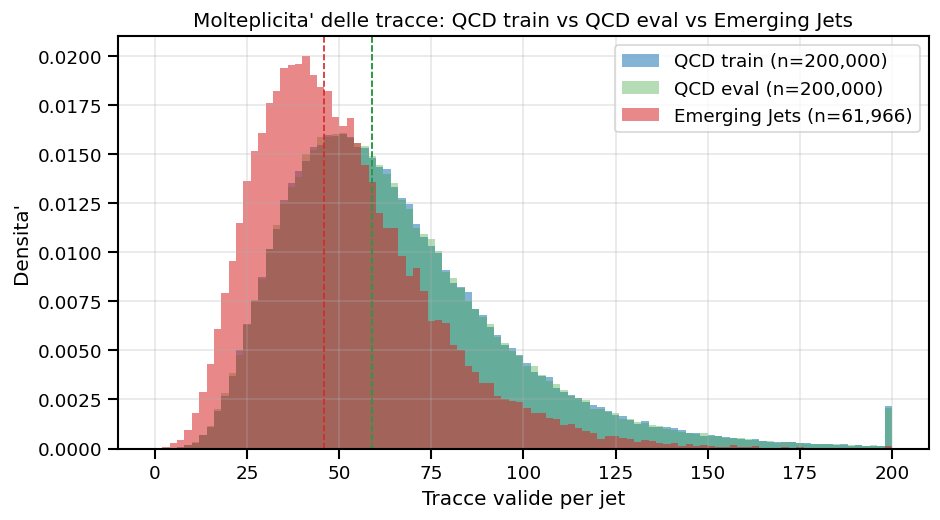

In [8]:
n_bkg  = mask_bkg.sum(1)
n_eval = mask_eval.sum(1)
n_sig  = mask_sig.sum(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.arange(0, MAX_TRACKS + 2, 2)

ax.hist(n_bkg,  bins=bins, density=True, alpha=0.55, color=COLOR_QCD, label=f"QCD train (n={len(n_bkg):,})")
ax.hist(n_eval, bins=bins, density=True, alpha=0.35, color="tab:green", label=f"QCD eval (n={len(n_eval):,})")
ax.hist(n_sig,  bins=bins, density=True, alpha=0.55, color=COLOR_EJ, label=f"Emerging Jets (n={len(n_sig):,})")

ax.axvline(np.median(n_bkg),  color=COLOR_QCD, ls="--", lw=1)
ax.axvline(np.median(n_eval), color="tab:green", ls="--", lw=1)
ax.axvline(np.median(n_sig),  color=COLOR_EJ, ls="--", lw=1)

ax.set_xlabel("Tracce valide per jet")
ax.set_ylabel("Densita'")
ax.set_title("Molteplicita' delle tracce: QCD train vs QCD eval vs Emerging Jets")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_multiplicity.png", bbox_inches="tight", dpi=150)
plt.show()


### 5.2 Distribuzioni delle feature di traccia: QCD vs EJ
Sovrapponiamo le distribuzioni sulle tracce valide. Le feature che "separano" i due colori sono quelle
da cui il modello potra' imparare.

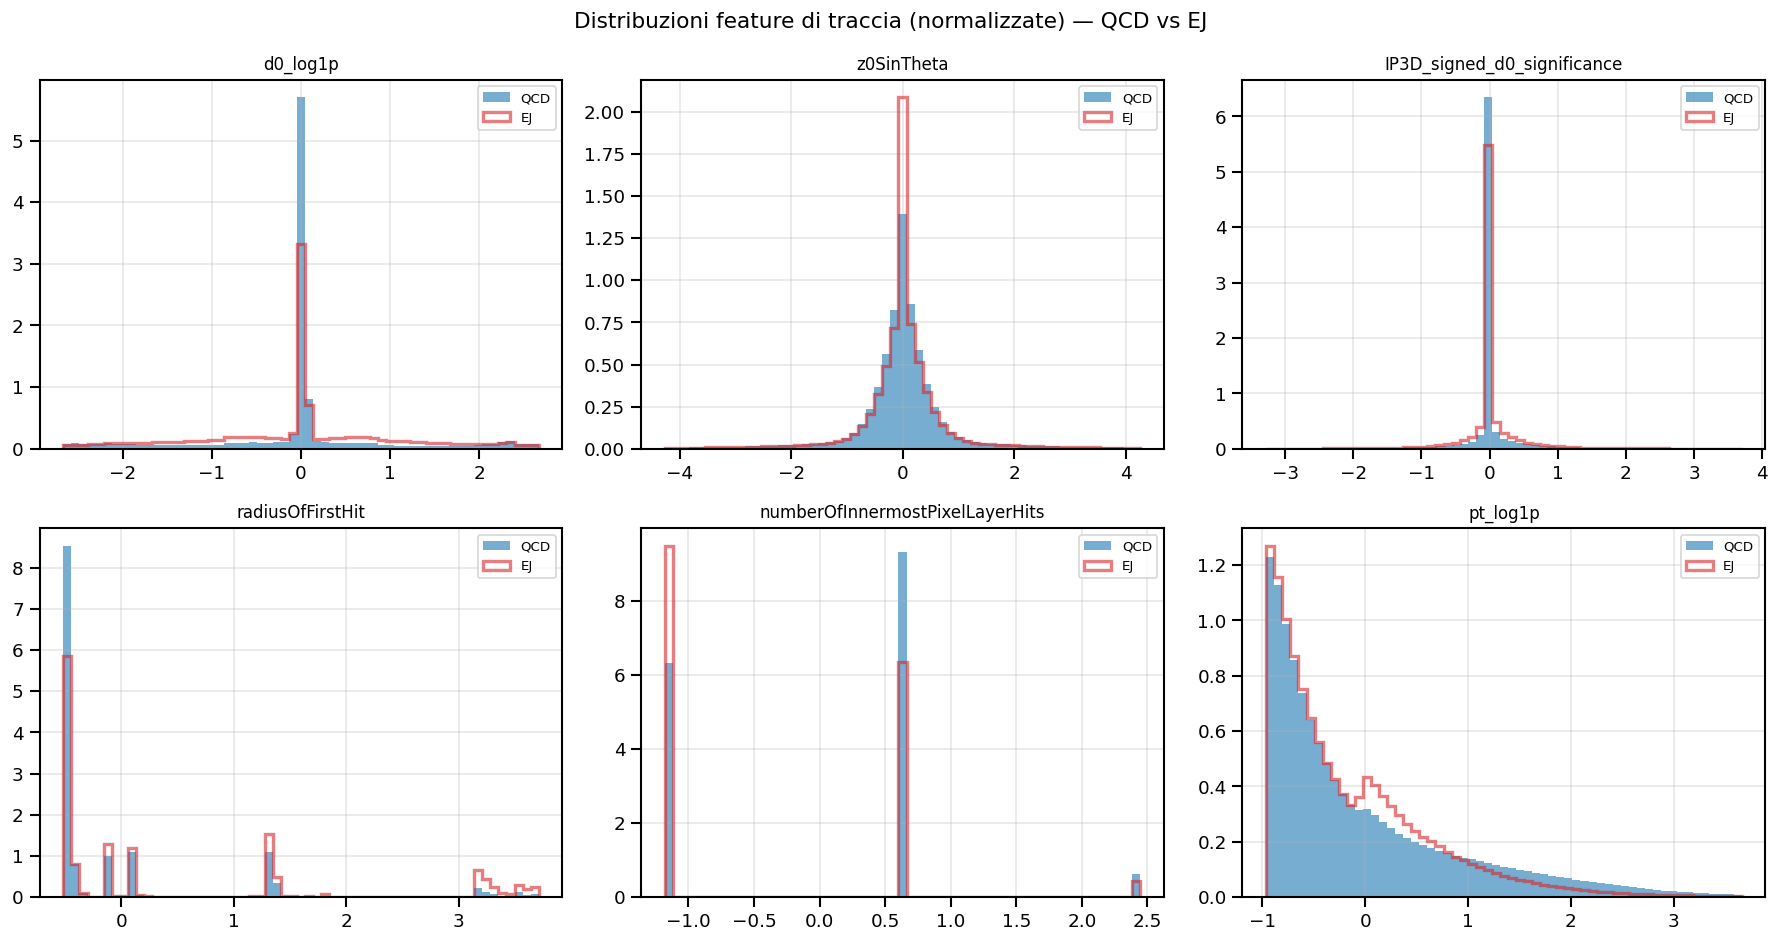

In [9]:
show = ["d0_log1p", "z0SinTheta", "IP3D_signed_d0_significance",
        "radiusOfFirstHit", "numberOfInnermostPixelLayerHits", "pt_log1p"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, show):
    j = TRACK_FEATURES.index(feat)
    b = Xt_bkg[:, :, j][mask_bkg]
    s = Xt_sig[:, :, j][mask_sig]
    lo, hi = np.percentile(np.concatenate([b, s]), [0.5, 99.5])
    bb = np.linspace(lo, hi, 60)
    ax.hist(b, bins=bb, density=True, alpha=0.6, color=COLOR_QCD, label="QCD")
    ax.hist(s, bins=bb, density=True, alpha=0.6, color=COLOR_EJ, histtype="step", lw=2, label="EJ")
    ax.set_title(feat, fontsize=10); ax.legend(fontsize=8)
fig.suptitle("Distribuzioni feature di traccia (normalizzate) — QCD vs EJ", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_track_distributions.png", bbox_inches="tight", dpi=150); plt.show()

### 5.3 Effetto del cleaning sul sentinella −999
Mostriamo `Tau21` PRIMA (dati grezzi, con il picco a −999) e DOPO il cleaning. Senza la gestione del
sentinella, quel picco diventerebbe un outlier a decine di σ.

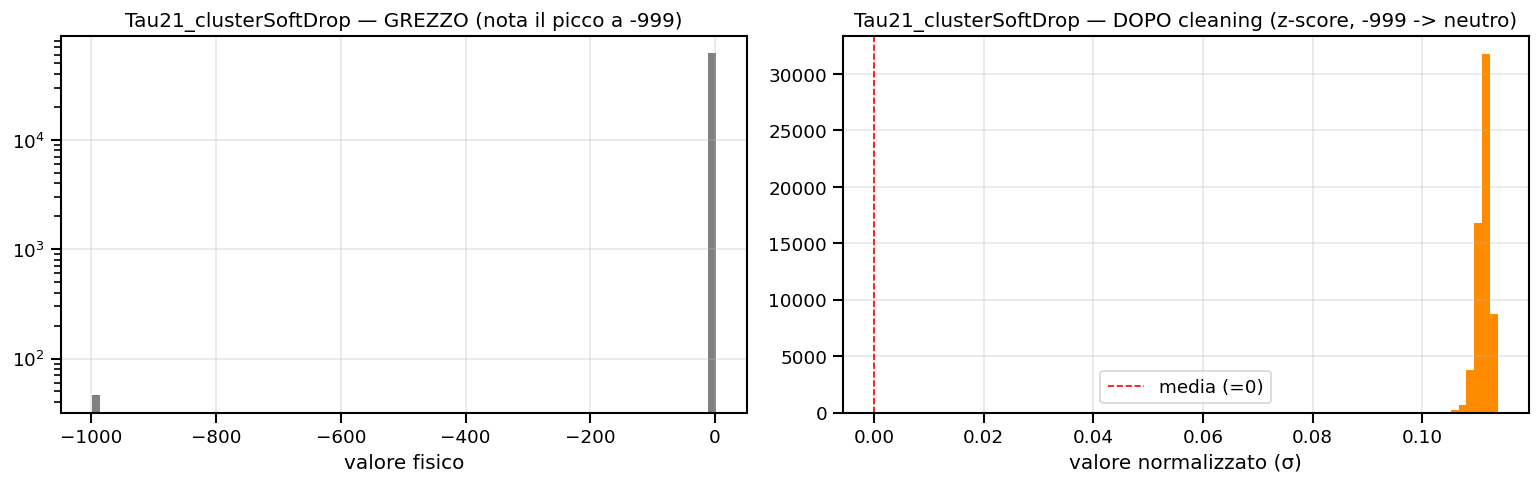

Frazione -999 nei dati grezzi: 0.074%


In [10]:
feat = "Tau21_clusterSoftDrop"
with h5py.File(SIG_FILE, "r") as f:
    raw = f["jets"][feat][:N_JETS].astype(np.float32)
j = JET_FEATURES.index(feat)
clean_vals = Xj_sig[:, j]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(raw, bins=80, color="gray")
axes[0].set_title(f"{feat} — GREZZO (nota il picco a -999)")
axes[0].set_xlabel("valore fisico"); axes[0].set_yscale("log")
axes[1].hist(clean_vals, bins=80, color="darkorange")
axes[1].axvline(0, color="red", ls="--", lw=1, label="media (=0)")
axes[1].set_title(f"{feat} — DOPO cleaning (z-score, -999 -> neutro)")
axes[1].set_xlabel("valore normalizzato (σ)"); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_sentinel_cleaning.png", bbox_inches="tight", dpi=150); plt.show()
print(f"Frazione -999 nei dati grezzi: {(raw <= -100).mean():.3%}")

### 5.4 Matrice di correlazione (a livello di traccia): QCD, EJ e differenza
Aggreghiamo le tracce per jet (media sulle tracce valide) e calcoliamo la correlazione di Pearson fra
feature:

- +1 → quando una feature sale, l'altra sale proporzionalmente.
- −1 → quando una sale, l'altra scende (opposte).
- 0 → nessuna relazione lineare (indipendenti).

NOTA: La terza matrice mostra dove la struttura di correlazione cambia tra segnale e fondo (EJ-QCD). Ha una scala più stretta (vlim=0.4 invece di 1) e una palette diversa (RdBu_r): serve proprio a ingrandire le differenze, che altrimenti sarebbero piccole e invisibili.
Le celle colorate indicano coppie di feature che si "agganciano" in modo diverso nel segnale rispetto al fondo, quelle coppie sono le tue "leve" discriminanti.

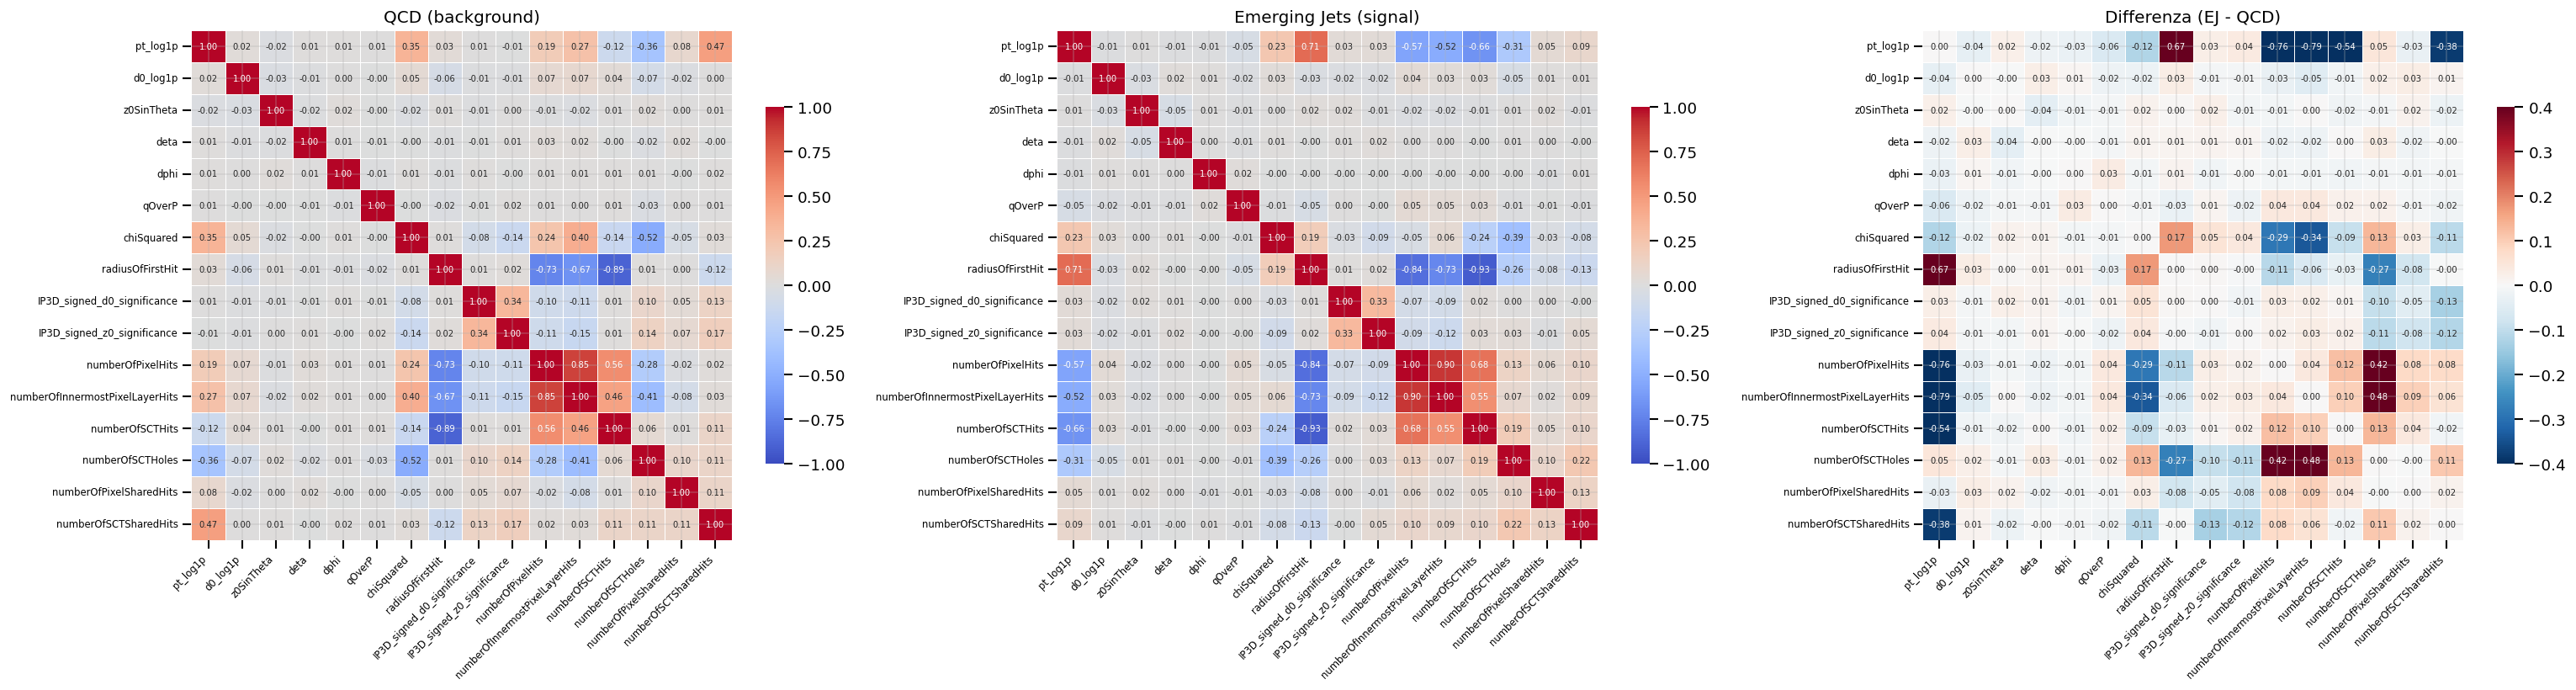

In [11]:
def agg_mean_per_jet(X, mask):
    keep = mask.sum(1) > 0
    Xk, mk = X[keep], mask[keep]
    m = mk[:, :, None].astype(np.float32)
    n = np.maximum(mk.sum(1, keepdims=True), 1).astype(np.float32)
    return (Xk * m).sum(1) / n

rng = np.random.default_rng(42)
def sub(X, mask, k=10_000):
    if len(X) <= k: return X, mask
    idx = rng.choice(len(X), k, replace=False); return X[idx], mask[idx]

c_bkg = np.corrcoef(agg_mean_per_jet(*sub(Xt_bkg, mask_bkg)).T)
c_sig = np.corrcoef(agg_mean_per_jet(*sub(Xt_sig, mask_sig)).T)
c_diff = c_sig - c_bkg

fig, axes = plt.subplots(1, 3, figsize=(26, 7))
for cm, axx, ttl, cmap, vlim in [
    (c_bkg, axes[0], "QCD (background)", "coolwarm", 1),
    (c_sig, axes[1], "Emerging Jets (signal)", "coolwarm", 1),
    (c_diff, axes[2], "Differenza (EJ - QCD)", "RdBu_r", 0.4)]:
    sns.heatmap(cm, ax=axx, annot=True, fmt=".2f", cmap=cmap, vmin=-vlim, vmax=vlim,
                xticklabels=TRACK_FEATURES, yticklabels=TRACK_FEATURES,
                linewidths=0.5, linecolor="white", annot_kws={"size": 6}, cbar_kws={"shrink": .7})
    axx.set_title(ttl, fontsize=12); axx.tick_params(labelsize=7)
    axx.set_xticklabels(axx.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_correlation.png", bbox_inches="tight", dpi=140); plt.show()

## 6. Rappresentazione — Embedding aggregato (jet + statistiche tracce)

Ogni jet ha un numero variabile di tracce, ma i modelli (come l'autoencoder ad esempio) vogliono un input di dimensione fissa. 
Allora si riassumono le tracce con delle statistiche. Invece di tenere tutte le tracce, per ogni feature di traccia calcolo qualche numero che ne descrive la distribuzione (la media, quanto sono sparse, il valore tipico, gli estremi...). Così, indipendentemente da quante tracce ci sono, ottengo sempre lo stesso numero di valori.


Per ogni jet costruiamo un vettore a lunghezza fissa, che contiene:
- le 15 **feature di jet** normalizzate;
- per ognuna delle 16 feature di traccia, **5 statistiche robuste** sulle tracce valide: `mean, std, median, q90, max`
  (mediana e 90° percentile rendono l'aggregato meno sensibile agli outlier);
- `log(1 + n_tracce)` → quante tracce ha il jet (in scala log).

Totale: 15 + 1 + 16×5 = 96 numeri per jet. E' l'input ideale per autoencoder/VAE. 

In [12]:
def aggregate_tracks(X, mask):
    n_valid = mask.sum(1, keepdims=True).astype(np.float32)        # (N,1)
    valid = np.where(mask[:, :, None], X, np.nan)                  # padding -> nan
    mean   = np.nanmean(valid, axis=1)
    std    = np.nanstd(valid, axis=1)
    median = np.nanmedian(valid, axis=1)
    q90    = np.nanpercentile(valid, 90, axis=1)
    mx     = np.nanmax(valid, axis=1)
    out = np.concatenate([np.log1p(n_valid), mean, std, median, q90, mx], axis=1)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)  # jet vuoti -> 0

def build_embedding(Xj, Xt, mask):
    return np.concatenate([Xj, aggregate_tracks(Xt, mask)], axis=1).astype(np.float32)

# NB: l'ordine dei nomi segue esattamente la concatenazione:
AGG_NAMES = list(JET_FEATURES) + ["log_n_tracks"]
for s in ["mean", "std", "median", "q90", "max"]:
    AGG_NAMES += [f"{f}_{s}" for f in TRACK_FEATURES]

E_bkg  = build_embedding(Xj_bkg,  Xt_bkg,  mask_bkg)
E_eval = build_embedding(Xj_eval, Xt_eval, mask_eval)
E_sig  = build_embedding(Xj_sig,  Xt_sig,  mask_sig)

# Standardizzazione finale dell'embedding:
# fit SOLO sul QCD train, applicata poi a QCD eval e signal.
e_mean = E_bkg.mean(0, keepdims=True)
e_std  = np.maximum(E_bkg.std(0, keepdims=True), 1e-8)

E_bkg_n  = ((E_bkg  - e_mean) / e_std).astype(np.float32)
E_eval_n = ((E_eval - e_mean) / e_std).astype(np.float32)
E_sig_n  = ((E_sig  - e_mean) / e_std).astype(np.float32)

print(f"Embedding: {E_bkg_n.shape[1]} dim/jet  =  {N_JF} jet + 1 + {N_TF}×5 track-stats")
print(f"  QCD train: {E_bkg_n.shape}")
print(f"  QCD eval : {E_eval_n.shape}")
print(f"  EJ signal: {E_sig_n.shape}")
assert len(AGG_NAMES) == E_bkg_n.shape[1]


Embedding: 96 dim/jet  =  15 jet + 1 + 16×5 track-stats
  QCD train: (200000, 96)
  QCD eval : (200000, 96)
  EJ signal: (61966, 96)


## 7. Diagnostica anti-leakage 

###  **Esame 1** — AUC di ogni singola feature (QCD vs EJ)
 Se una singola feature avesse AUC ~0.99, sarebbe un campanello d'allarme rosso: vorrebbe dire che quella feature da sola "sa già la risposta" → probabilmente è una label mascherata o un leak (è esattamente il motivo per cui avete escluso displacedPtFraction). 

### **Esame 2** — Consistenza dei due background (QCD train vs QCD eval)
 Qui proviamo a distinguere il QCD-train dal QCD-eval con un classificatore. Ma sono lo stesso tipo di dato (entrambi QCD)! Quindi un buon classificatore non dovrebbe riuscirci: l'AUC ideale è 0.5 (tira a indovinare). Se l'AUC fosse alta (es. 0.7), vorrebbe dire che train ed eval sono diversi (magari diversa cinematica, diverso run...), e allora ciò che il modello chiama "anomalia" sull'eval potrebbe essere solo "background un po' diverso", non vero segnale.

### **Esame 3** — Baseline supervisionata (l'upper bound)
 Qui usiamo le label EJ in addestramento, ma solo come metro di paragone: alleniamo un classificatore lineare supervisionato con tutte le 96 feature. Ci dice: "se conoscessi le risposte e usassi un modello semplice, quanto separerei?". Risultato: 0.9864. Questo è il tetto "facile" del problema.  È il riferimento contro cui giudicare i modelli non supervisionati.

In [13]:
# Diagnostica 1: singole feature QCD train vs EJ.
# Serve solo per capire quali feature sono piu' informative
y = np.concatenate([np.zeros(len(E_bkg_n)), np.ones(len(E_sig_n))])
X_all = np.concatenate([E_bkg_n, E_sig_n], axis=0)

rows = []
for i, name in enumerate(AGG_NAMES):
    a = roc_auc_score(y, X_all[:, i])
    rows.append((name, max(a, 1 - a)))   # max(a,1-a): direzione irrilevante
rows.sort(key=lambda r: r[1], reverse=True)

print("Top 15 feature per AUC singola QCD train vs EJ:")
for name, a in rows[:15]:
    print(f"  {name:38s} AUC={a:.4f}")

# Diagnostica 2: QCD train vs QCD eval.
# Deve stare vicino a 0.5: se e' alto, train/eval background sono tanto diversi e usare questo eval non va bene
n_check = min(len(E_bkg_n), len(E_eval_n))
X_bgcheck = np.concatenate([E_bkg_n[:n_check], E_eval_n[:n_check]], axis=0)
y_bgcheck = np.concatenate([np.zeros(n_check), np.ones(n_check)], axis=0)

Xtr_bg, Xte_bg, ytr_bg, yte_bg = train_test_split(
    X_bgcheck, y_bgcheck, test_size=0.3, random_state=42, stratify=y_bgcheck
)
clf_bg = LogisticRegression(max_iter=3000).fit(Xtr_bg, ytr_bg)
auc_bg = roc_auc_score(yte_bg, clf_bg.predict_proba(Xte_bg)[:, 1])
print(f"\nBackground consistency check train QCD vs eval QCD: AUC = {auc_bg:.4f} (ideale ~0.5)")

# Diagnostica 3: Baseline supervisionata QCD train vs EJ.
# E' un upper bound diagnostico
Xtr, Xte, ytr, yte = train_test_split(X_all, y, test_size=0.3, random_state=42, stratify=y)
clf = LogisticRegression(max_iter=3000).fit(Xtr, ytr)
auc_lr = roc_auc_score(yte, clf.predict_proba(Xte)[:, 1])
print(f"Baseline logistic regression QCD vs EJ: AUC = {auc_lr:.4f}")


Top 15 feature per AUC singola QCD train vs EJ:
  Tau2_clusterSoftDrop                   AUC=0.8738
  numberOfSCTSharedHits_mean             AUC=0.8721
  Tau3_clusterSoftDrop                   AUC=0.8563
  numberOfSCTSharedHits_std              AUC=0.8553
  Tau1_clusterSoftDrop                   AUC=0.8551
  numberOfInnermostPixelLayerHits_mean   AUC=0.8485
  radiusOfFirstHit_median                AUC=0.8437
  Tau4_clusterSoftDrop                   AUC=0.8408
  numberOfPixelHits_mean                 AUC=0.8310
  numberOfSCTSharedHits_q90              AUC=0.8209
  C2_clusterSoftDrop                     AUC=0.8171
  pt_log1p_std                           AUC=0.8148
  radiusOfFirstHit_mean                  AUC=0.8134
  numberOfPixelHits_median               AUC=0.8064
  pt_log1p_q90                           AUC=0.8004

Background consistency check train QCD vs eval QCD: AUC = 0.5007 (ideale ~0.5)
Baseline logistic regression QCD vs EJ: AUC = 0.9872


**RISULTATO ESAME 1**: Nessuna è vicina a 1 --> cioè il potere discriminante è distribuito su tante feature fisiche (hit pattern, sottostruttura Tau, raggio prima hit...), non concentrato in un'unica variabile sospetta. Significa che il segnale è reale e fisico, non un artefatto da leakage, e le feature in cima hanno senso fisico — numberOfSCTSharedHits (hit condivisi nel rivelatore, legati a tracce displaced/affollate), le Tau (sottostruttura). Tutto coerente con la fisica degli EJ.

**RISULTATO ESAME 2**:  I due background sono statisticamente identici (AUC~0.5) → possiamo fidarci dell'eval come riferimento pulito.

**RISULTATO ESAME 3**: il risultato di AUC trovato rappresenta il tetto supervisionato.

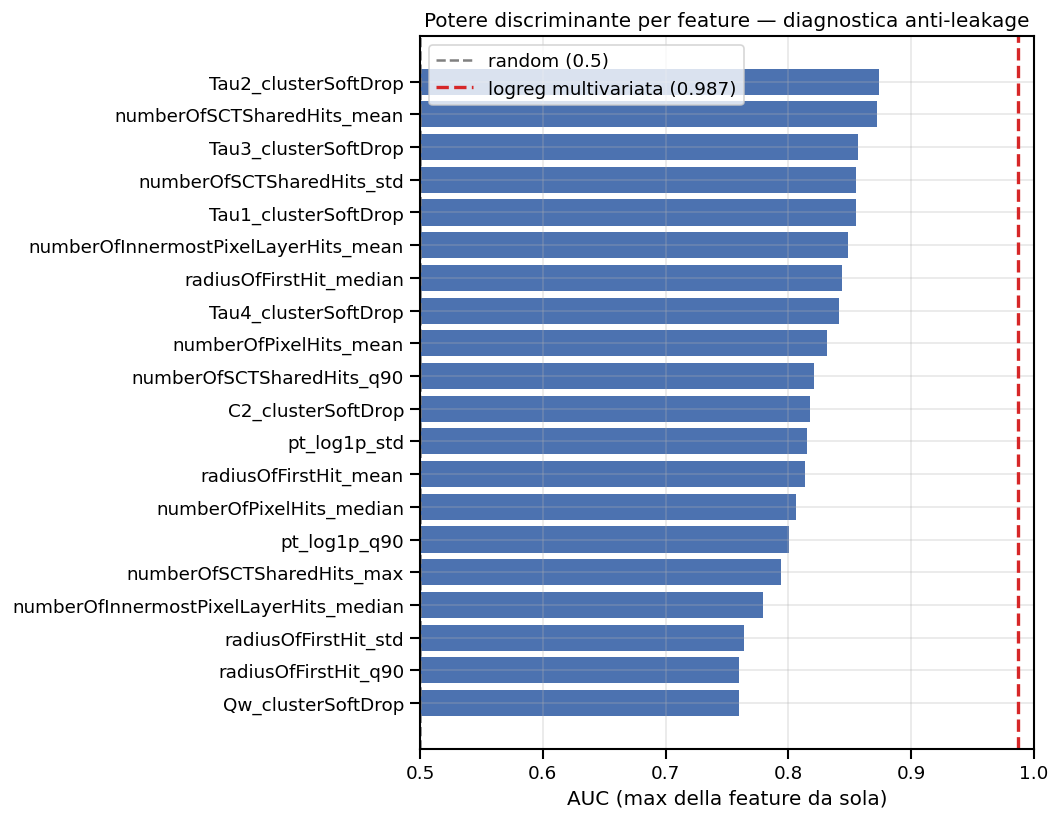

In [14]:
# Grafico: top-20 AUC per singola feature + linea della baseline
top = rows[:20]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh([t[0] for t in top][::-1], [t[1] for t in top][::-1], color="#4c72b0") # le barre sono il potere di ogni feature da sola
ax.axvline(0.5, color="gray", ls="--", label="random (0.5)")
ax.axvline(auc_lr, color=COLOR_EJ, ls="--", lw=2, label=f"logreg multivariata ({auc_lr:.3f})")
ax.set_xlabel("AUC (max della feature da sola)"); ax.set_xlim(0.5, 1.0)
ax.set_title("Potere discriminante per feature — diagnostica anti-leakage")
ax.legend(); plt.tight_layout()
plt.savefig(OUT_DIR / "fig_feature_auc.png", bbox_inches="tight", dpi=150); plt.show()

## 8. Rappresentazione 2 — Sequenze padded
Nella Rappr. 1 avevamo buttato via le singole tracce, riassumendole in statistiche. Qui facciamo l'opposto: teniamo tutte le tracce, una per una. Ogni jet diventa una sequenza di tracce — come una frase è una sequenza di parole. La forma è un tensore (N, 200, 16) + una mask. Cioè: N jet × 200 slot-traccia × 16 feature. Gli slot non usati sono padding (a 0), e la mask dice al Transformer quali ignorare (così non "presta attenzione" a tracce-fantasma).

Questo serve ai Transformer, modelli nati per il linguaggio, che sono bravissimi a guardare un insieme di elementi e capire come si relazionano tra loro. A differenza della Rappr. 1, qui il modello vede i dettagli di ogni traccia, non solo il riassunto.


----------------------------------------------------------------------------------------------------------------------------------------------

Tensore `(N, MAX_TRACKS, F)` + maschera booleana. Le tracce sono **ordinate**: di default per `pt`
decrescente (ordine naturale), in alternativa per `|d0|` decrescente (mette le tracce displaced — la
firma EJ — nei primi slot, utile per Transformer).

Questo perchè le tracce, di per sé, non hanno un ordine naturale, ma **dare un ordine coerente aiuta il modello**.

In [15]:
def sort_tracks(X, mask, by="pt"):
    idx = TRACK_FEATURES.index("pt_log1p") if by == "pt" else TRACK_FEATURES.index("d0_log1p") #ordina per impulso trasverso decrescente
    key = (np.abs(X[:, :, idx]) if by == "d0" else X[:, :, idx]).copy() #ordina per |d0| decrescente: mette le tracce più displaced nei primi slot così la firma del segnale finisce in testa alla sequenza, dove un Transformer la "nota" subito.
    key[~mask] = -1e9  #assegna ai padding un valore enorme negativo → finiscono sempre in fondo all'ordinamento, mai mescolati alle tracce vere.
    order = np.argsort(-key, axis=1) #il - trasforma il crescente in decrescente (NumPy ordina solo in crescente).
    return (np.take_along_axis(X, order[:, :, None], axis=1), #applica lo stesso riordino sia ai dati X che alla mask, così restano allineati.
            np.take_along_axis(mask, order, axis=1))

Xt_bkg_seq,  mask_bkg_seq  = sort_tracks(Xt_bkg,  mask_bkg,  by="pt")
Xt_eval_seq, mask_eval_seq = sort_tracks(Xt_eval, mask_eval, by="pt")
Xt_sig_seq,  mask_sig_seq  = sort_tracks(Xt_sig,  mask_sig,  by="pt")

assert mask_bkg_seq[:, 0].all(), "lo slot 0 deve essere sempre occupato dopo l'ordinamento" #Controllo automatico: dopo l'ordinamento, lo slot 0 deve contenere una traccia vera per ogni jet
print("Sequenze:")
print("  QCD train:", Xt_bkg_seq.shape,  "| padding:", f"{(~mask_bkg_seq).mean()*100:.1f}% degli slot")
print("  QCD eval :", Xt_eval_seq.shape, "| padding:", f"{(~mask_eval_seq).mean()*100:.1f}% degli slot")
print("  EJ signal:", Xt_sig_seq.shape,  "| padding:", f"{(~mask_sig_seq).mean()*100:.1f}% degli slot")


Sequenze:
  QCD train: (200000, 200, 16) | padding: 67.6% degli slot
  QCD eval : (200000, 200, 16) | padding: 67.7% degli slot
  EJ signal: (61966, 200, 16) | padding: 74.8% degli slot


## 9. Rappresentazione 3 — Grafi kNN
Terzo modo di vedere un jet: come un grafo (una rete di punti connessi). I nodi sono le tracce; gli archi collegano ogni traccia ai suoi k vicini più prossimi (kNN, qui k=8). Questo serve alle Graph Neural Network (GNN), che imparano dalla struttura di vicinanza — "questa traccia, insieme alle sue vicine, forma un pattern normale o anomalo?".

Ogni jet diventa un grafo: **nodi** = tracce valide, **archi** = k vicini piu' prossimi. Costruiamo i
grafi in **due spazi** complementari:
- **Spazio η–φ**: collega tracce spazialmente vicine nel rivelatore (struttura di sub-jet);
- **Spazio dei parametri d'impatto (IP3D d0 sig, IP3D z0 sig)**: tracce dallo stesso vertice displaced finiscono vicine → connette preferenzialmente i costituenti di un decadimento secondario (la firma EJ).


In [16]:
def build_knn_graph(x_jet, mask_jet, space="etaphi", k=KNN_K):
    vi = np.where(mask_jet)[0] # indici delle tracce valide
    n = len(vi)
    if n == 0:
        return None
    xv = x_jet[vi]  # solo tracce reali (niente padding nel grafo)
    if space == "etaphi":
        cols = [TRACK_FEATURES.index("deta"), TRACK_FEATURES.index("dphi")]
    else:
        cols = [TRACK_FEATURES.index("IP3D_signed_d0_significance"),
                TRACK_FEATURES.index("IP3D_signed_z0_significance")]
    coords = xv[:, cols] # le 2 coordinate dello spazio scelto
    k_eff = min(k, n - 1)  # non posso avere più vicini delle tracce disponibili
    if k_eff <= 0:
        src = dst = np.array([0]); ea = np.zeros((1, 2), np.float32)
    else:
        nn = NearestNeighbors(n_neighbors=k_eff + 1).fit(coords)
        _, ind = nn.kneighbors(coords)
        src = np.repeat(np.arange(n), k_eff)
        dst = ind[:, 1:].flatten()   # [:, 1:] esclude se stesso (il vicino #0 è il nodo stesso)
        ea = (coords[dst] - coords[src]).astype(np.float32)  # attributo dell'arco = distanza vettoriale
    if HAS_PYG:
        return Data(x=torch.tensor(xv, dtype=torch.float32),
                    edge_index=torch.tensor(np.stack([src, dst]), dtype=torch.long),
                    edge_attr=torch.tensor(ea, dtype=torch.float32), num_nodes=n)
    return {"x": xv, "edge_index": np.stack([src, dst]), "edge_attr": ea, "num_nodes": n}

def build_graphs(X, mask, space="etaphi", k=KNN_K, limit=N_GRAPH_DEMO):
    out = []
    for i in range(min(limit, len(X))):
        g = build_knn_graph(X[i], mask[i], space, k)
        if g is not None:
            out.append(g)
    return out

graphs_bkg  = build_graphs(Xt_bkg,  mask_bkg,  space="etaphi") 
graphs_eval = build_graphs(Xt_eval, mask_eval, space="etaphi")
graphs_sig  = build_graphs(Xt_sig,  mask_sig,  space="etaphi")
print(f"Grafi η-φ costruiti: QCD train={len(graphs_bkg):,} | QCD eval={len(graphs_eval):,} | EJ={len(graphs_sig):,} | PyG={HAS_PYG}")


Grafi η-φ costruiti: QCD train=4,000 | QCD eval=4,000 | EJ=4,000 | PyG=False


### 9.1 Visualizzazione dei grafi: QCD vs Emerging Jet

Mostriamo un grafo per tipo nello spazio η–φ. **Il modello si allena sul QCD** : impara a
"ricostruire" la struttura tipica di un jet ordinario. In questo modo possiamo vedere la differenza di struttura: il QCD  tende ad avere una geometria più "compatta/regolare", l'EJ una più sparsa/diversa.

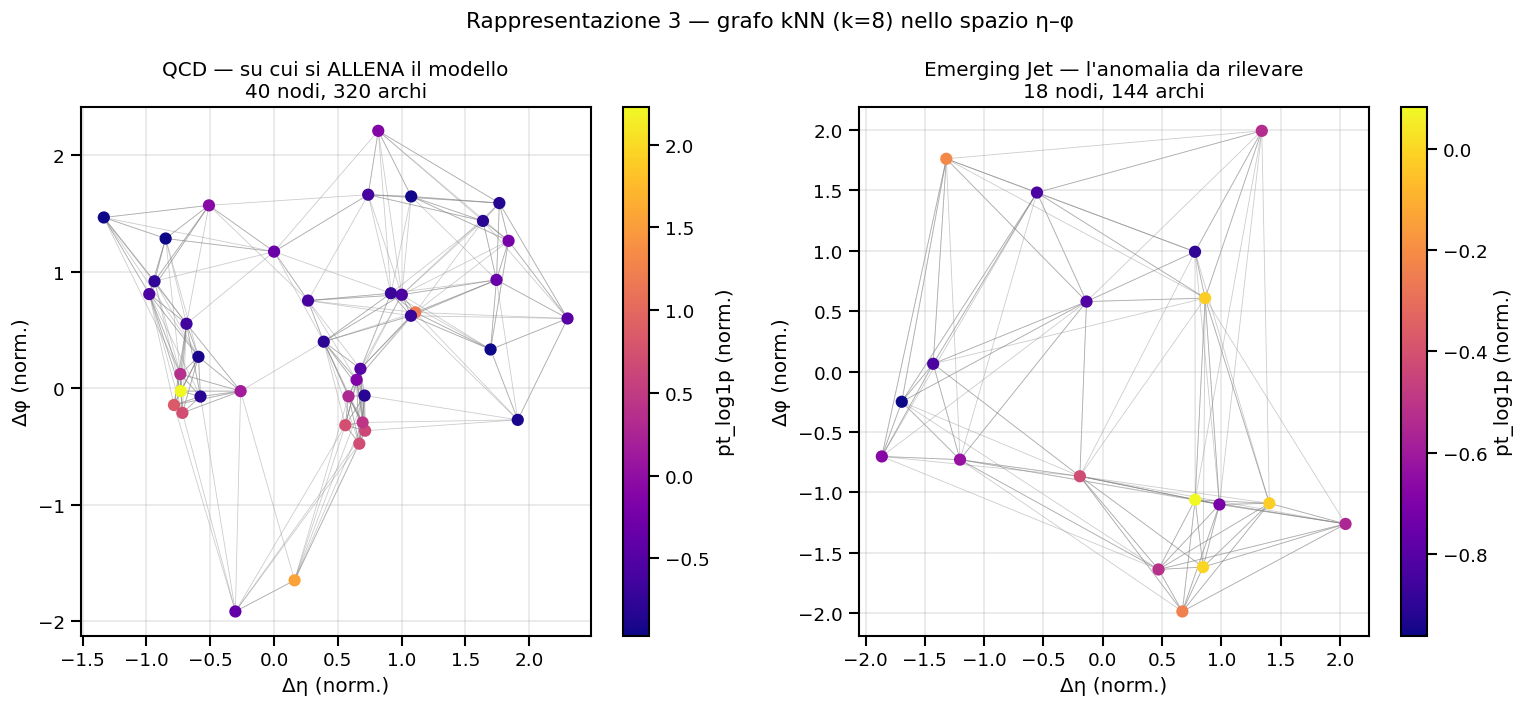

In [17]:
def get(g, key):
    if HAS_PYG:
        return g.x.numpy() if key == "x" else g.edge_index.numpy()
    return g[key]

de, dp = TRACK_FEATURES.index("deta"), TRACK_FEATURES.index("dphi")
pti = TRACK_FEATURES.index("pt_log1p")

def readable(glist): # serve a sceglie un jet con 15-50 nodi, così il disegno è leggibile e non un groviglio.
    # primo grafo con un numero di nodi "leggibile" per il disegno
    for g in glist:
        if 15 <= get(g, "x").shape[0] <= 50:
            return g
    return glist[0] if glist else None

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, glist, ttl in [(axes[0], graphs_bkg, "QCD — su cui si ALLENA il modello"),
                       (axes[1], graphs_sig, "Emerging Jet — l'anomalia da rilevare")]:
    g = readable(glist)
    if g is None:
        continue
    xg, ei = get(g, "x"), get(g, "edge_index")
    for s, d in zip(ei[0], ei[1]):
        ax.plot([xg[s, de], xg[d, de]], [xg[s, dp], xg[d, dp]],
                color="gray", lw=0.5, alpha=0.4, zorder=1)
    sc = ax.scatter(xg[:, de], xg[:, dp], c=xg[:, pti], cmap="plasma", s=40, zorder=2)
    plt.colorbar(sc, ax=ax, label="pt_log1p (norm.)")
    ax.set_xlabel("Δη (norm.)"); ax.set_ylabel("Δφ (norm.)")
    ax.set_title(f"{ttl}\n{xg.shape[0]} nodi, {ei.shape[1]} archi")
fig.suptitle(f"Rappresentazione 3 — grafo kNN (k={KNN_K}) nello spazio η–φ", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_knn_graph.png", bbox_inches="tight", dpi=150); plt.show()

## 10. Salvataggio delle rappresentazioni

Tutto in `FINAL/processed/`. I notebook dei modelli caricheranno questi file senza rifare il preprocessing.

In [18]:
# Rappr. 1 — embedding aggregato 
np.savez_compressed(
    OUT_DIR / "repr1_aggregate.npz",
    bkg_train=E_bkg_n,
    bkg_eval=E_eval_n,
    sig=E_sig_n,
    feature_names=np.array(AGG_NAMES, dtype=object),
    norm_mean=e_mean.astype(np.float32),
    norm_std=e_std.astype(np.float32),
)

# Rappr. 2 — sequenze padded
np.savez_compressed(
    OUT_DIR / "repr2_sequences.npz",
    X_bkg_train=Xt_bkg_seq,
    mask_bkg_train=mask_bkg_seq,
    X_bkg_eval=Xt_eval_seq,
    mask_bkg_eval=mask_eval_seq,
    X_sig=Xt_sig_seq,
    mask_sig=mask_sig_seq,
    jet_bkg_train=Xj_bkg,
    jet_bkg_eval=Xj_eval,
    jet_sig=Xj_sig,
    track_feature_names=np.array(TRACK_FEATURES, dtype=object),
    jet_feature_names=np.array(JET_FEATURES, dtype=object),
)

# Rappr. 3 — grafi
if HAS_PYG:
    torch.save(
        {"bkg_train": graphs_bkg, "bkg_eval": graphs_eval, "sig": graphs_sig},
        OUT_DIR / "repr3_graphs.pt",
    )
else:
    np.savez_compressed(
        OUT_DIR / "repr3_graphs.npz",
        bkg_train=np.array(graphs_bkg, dtype=object),
        bkg_eval=np.array(graphs_eval, dtype=object),
        sig=np.array(graphs_sig, dtype=object),
    )

# Metadati per notebook successivi
summary = {
    "n_bkg_train": int(len(E_bkg_n)),
    "n_bkg_eval": int(len(E_eval_n)),
    "n_sig": int(len(E_sig_n)),
    "n_jet_features": int(N_JF),
    "n_track_features": int(N_TF),
    "aggregate_dim": int(E_bkg_n.shape[1]),
    "clip_sigma": float(CLIP_SIGMA),
    "max_tracks": int(MAX_TRACKS),
    "uses_displacedPtFraction": bool(USE_DISPLACED_PT_FRACTION),
    "background_consistency_auc_train_vs_eval": float(auc_bg),
    "supervised_logreg_auc_qcd_vs_ej": float(auc_lr),
}

with open(OUT_DIR / "preprocessing_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Salvato in:", OUT_DIR)
for p in sorted(OUT_DIR.glob("repr*")):
    print("  -", p.name, f"({p.stat().st_size/1e6:.1f} MB)")
print("  - preprocessing_summary.json")


Salvato in: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed
  - repr1_aggregate.npz (138.9 MB)
  - repr2_gnn_light.npz (175.0 MB)
  - repr2_sequences.npz (1235.3 MB)
  - repr3_graphs.npz (82.4 MB)
  - preprocessing_summary.json


## 11. Riepilogo

| Rappresentazione | Shape | Modelli |
|---|---|---|
| 1 — Aggregato | `(N, n_jet + 1 + n_track×5)` | AE / VAE  |
| 2 — Sequenze | `(N, 200, n_track)` + mask |  Transformer  |
| 3 — Grafi kNN | lista di grafi (η–φ, impact) | GNN  |


In [19]:
print("="*60)
print("PREPROCESSING FINALE — RIEPILOGO")
print("="*60)
print(f"QCD train: {len(E_bkg_n):,} jet")
print(f"QCD eval : {len(E_eval_n):,} jet")
print(f"EJ eval  : {len(E_sig_n):,} jet")
print(f"Repr.1 aggregato : train {E_bkg_n.shape} | eval {E_eval_n.shape} | sig {E_sig_n.shape}")
print(f"Repr.2 sequenze  : train {Xt_bkg_seq.shape} | eval {Xt_eval_seq.shape} | sig {Xt_sig_seq.shape}")
print(f"Repr.3 grafi     : {len(graphs_bkg):,} train / {len(graphs_eval):,} eval / {len(graphs_sig):,} EJ")
print(f"Background train-vs-eval AUC: {auc_bg:.4f}  (ideale ~0.5)")
print(f"Baseline logreg QCD-vs-EJ AUC: {auc_lr:.4f}  (upper bound diagnostico)")


PREPROCESSING FINALE — RIEPILOGO
QCD train: 200,000 jet
QCD eval : 200,000 jet
EJ eval  : 61,966 jet
Repr.1 aggregato : train (200000, 96) | eval (200000, 96) | sig (61966, 96)
Repr.2 sequenze  : train (200000, 200, 16) | eval (200000, 200, 16) | sig (61966, 200, 16)
Repr.3 grafi     : 4,000 train / 4,000 eval / 4,000 EJ
Background train-vs-eval AUC: 0.5007  (ideale ~0.5)
Baseline logreg QCD-vs-EJ AUC: 0.9872  (upper bound diagnostico)
